<a href="https://colab.research.google.com/github/sournorm/-_3-8_-_-/blob/main/%D0%9F%D1%96%D0%B4%D1%81%D1%83%D0%BC%D0%BA%D0%BE%D0%B2%D0%B0_%D0%9A%D0%A0_%D0%97%D0%B0%D0%BF%D0%BE%D1%80%D0%BE%D0%B6%D0%B0%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Підсумкова Контрольна робота
Запорожан Сергій ФІТ 3-8

## Завдання 1: Global YouTube Statistics 2023

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

 2. перші п'ять рядків

In [4]:
print("--- Перші 5 рядків ---")
display(df_yt.head())

--- Перші 5 рядків ---


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


 3. Виведіть розміри датасету, перевірте наявність пропусків, дублікатів

In [5]:
print(f"\nРозмір датасету: {df_yt.shape}")
print(f"Кількість дублікатів: {df_yt.duplicated().sum()}")
print("\nПропуски до обробки:")
print(df_yt.isnull().sum())


Розмір датасету: (995, 28)
Кількість дублікатів: 0

Пропуски до обробки:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                     


Пропуски в числових стовпцях після обробки:
rank                                       0
subscribers                                0
video views                                0
uploads                                    0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_date                               0
Gross tertiary education enrollment (%)    0
Population                                 0
Unemployment rate                          0
Urban_population                           0
Latitude                                   0
Longitude                                  0
dtype: int

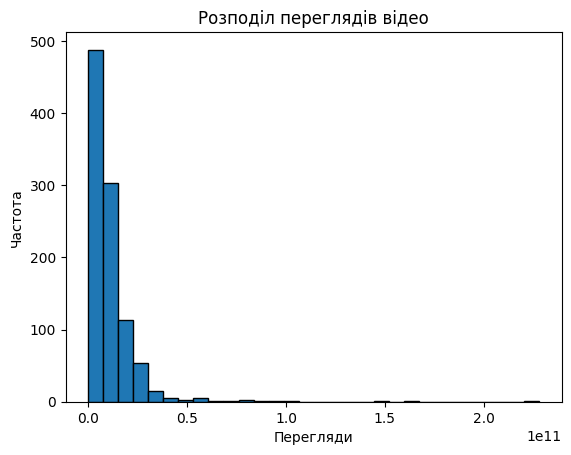

Перегляди - Максимум: 228000000000.0, Мінімум: 0.0, Середнє: 11039537052.03819
Країна з найбільшою кількістю завантажень: India
Канал з найбільшою кількістю завантажень: ABP NEWS
Канал з найменшою кількістю завантажень: Music


In [6]:
numeric_cols = df_yt.select_dtypes(include=['number']).columns
for col in numeric_cols:
    mean_val = df_yt[col].mean()
    df_yt[col] = df_yt[col].fillna(mean_val)
    df_yt[col] = df_yt[col].astype(float)

# 5.кількість пропусків.
print("\nПропуски в числових стовпцях після обробки:")
print(df_yt[numeric_cols].isnull().sum())

# 6. Перевірте, скільки унікальних країн представлено у колонці "Country"
unique_countries = df_yt['Country'].nunique()
print(f"\nКількість унікальних країн: {unique_countries}")

# 7. Побудуйте діаграму розподілу переглядів
df_yt['video views'].plot(kind='hist', bins=30, title='Розподіл переглядів відео', edgecolor='black')
plt.xlabel('Перегляди')
plt.ylabel('Частота')
plt.show()

# 8. Визначте максимальну, мінімальну, середню кількість переглядів
max_views = df_yt['video views'].max()
min_views = df_yt['video views'].min()
mean_views = df_yt['video views'].mean()
print(f"Перегляди - Максимум: {max_views}, Мінімум: {min_views}, Середнє: {mean_views}")

# 9. Знайдіть країну, де найбільше відео було завантажено на YouTube
top_country = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"Країна з найбільшою кількістю завантажень: {top_country}")

# 10. Знайдіть відео (канал) з найбільшою та найменшою кількістю завантажень
max_uploads_channel = df_yt.loc[df_yt['uploads'].idxmax(), 'Youtuber']
min_uploads_channel = df_yt.loc[df_yt['uploads'].idxmin(), 'Youtuber']
print(f"Канал з найбільшою кількістю завантажень: {max_uploads_channel}")
print(f"Канал з найменшою кількістю завантажень: {min_uploads_channel}")

## Завдання 2
Робота з файлом shopping_trends.csv та візуалізація за допомогою бібліотеки seaborn.

In [7]:
import seaborn as sns

In [8]:
df_shop = pd.read_csv('shopping_trends.csv')

Розмір таблиці: (3900, 19)

Пропуски:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи стовпців:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Rev

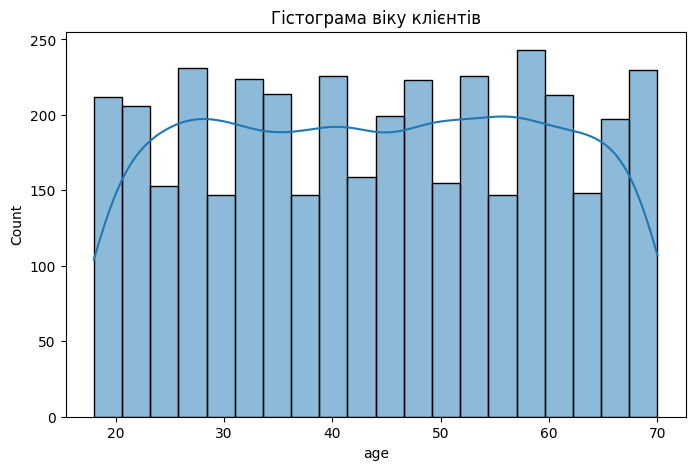

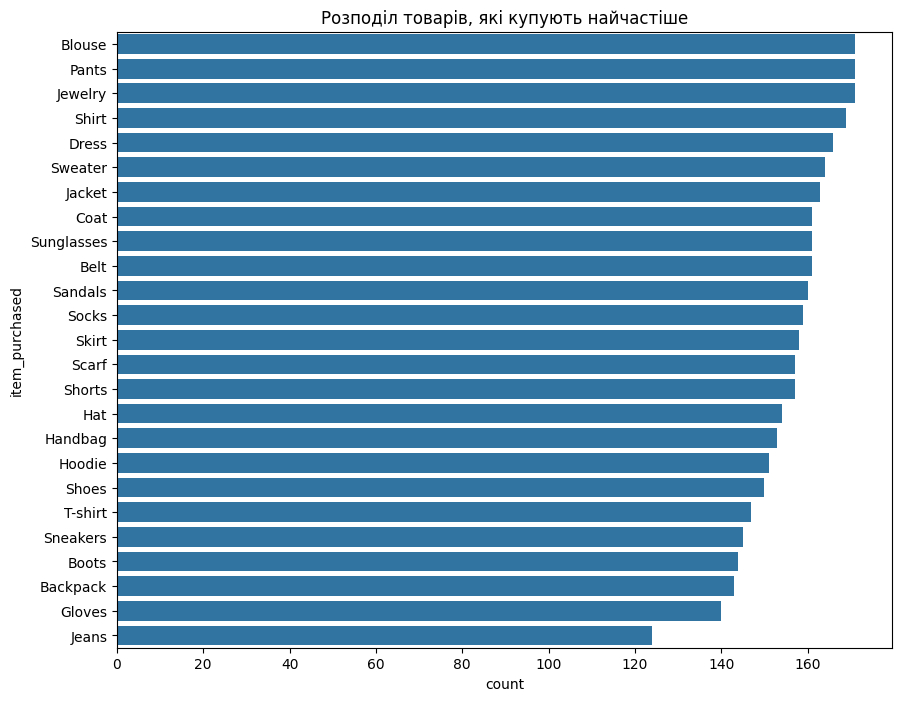

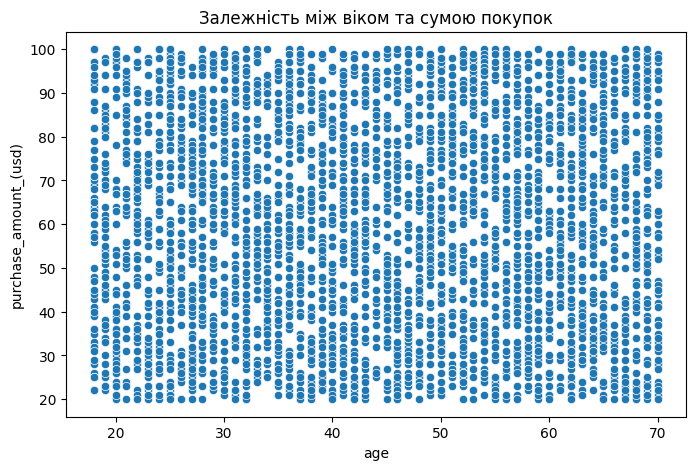

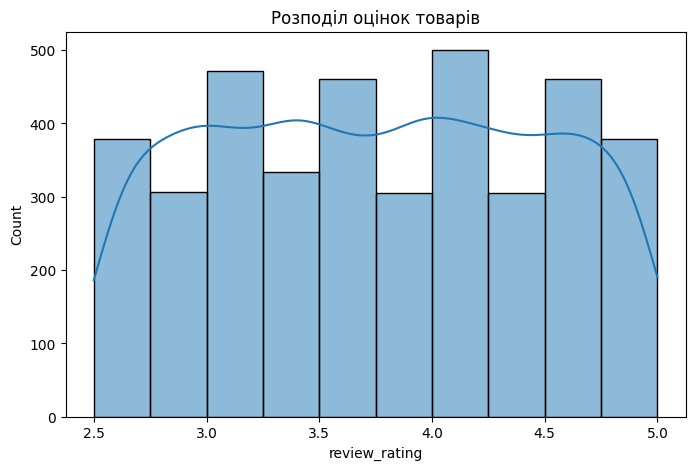

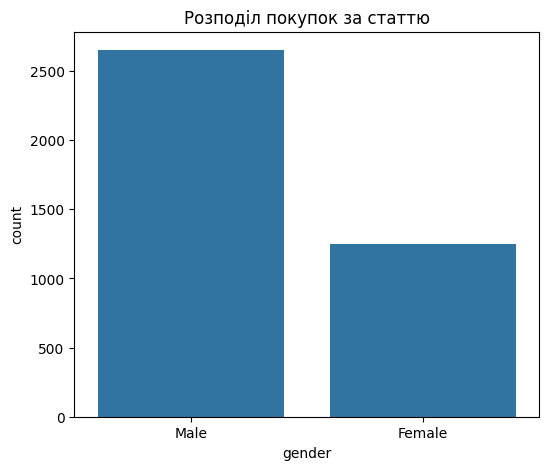

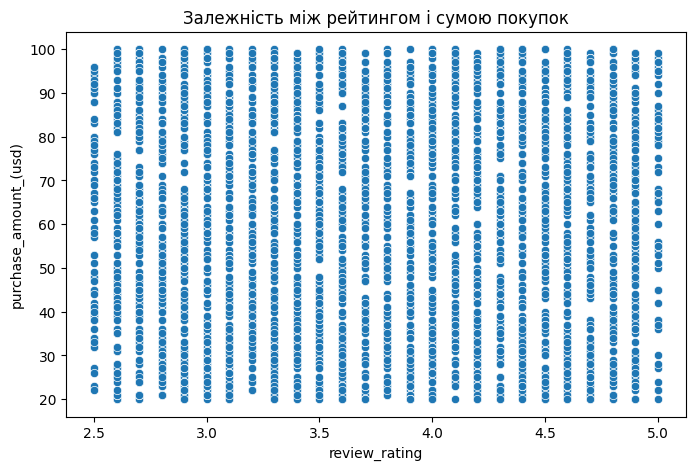

In [9]:
# розмір таблиці, наявність пропусків, тип стовпців.
print(f"Розмір таблиці: {df_shop.shape}")
print("\nПропуски:")
print(df_shop.isnull().sum())
print("\nТипи стовпців:")
print(df_shop.dtypes)

df_shop.columns = df_shop.columns.str.lower().str.replace(' ', '_')

# 1. Гістограма віку клієнтів (age)
plt.figure(figsize=(8, 5))
sns.histplot(data=df_shop, x='age', bins=20, kde=True)
plt.title('Гістограма віку клієнтів')
plt.show()

# 2-3. Порівняння розподілу покупок за товаром (item_purchased)
plt.figure(figsize=(10, 8))
sns.countplot(data=df_shop, y='item_purchased', order=df_shop['item_purchased'].value_counts().index)
plt.title('Розподіл товарів, які купують найчастіше')
plt.show()

# 4-5. Залежність між віком та сумою покупок (purchase_amount_usd)
col_purchase = 'purchase_amount_(usd)' if 'purchase_amount_(usd)' in df_shop.columns else 'purchase_amount'
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_shop, x='age', y=col_purchase)
plt.title('Залежність між віком та сумою покупок')
plt.show()

# 6-7. Графік розподілу оцінок товарів (review_rating)
plt.figure(figsize=(8, 5))
sns.histplot(data=df_shop, x='review_rating', bins=10, kde=True)
plt.title('Розподіл оцінок товарів')
plt.show()

# 8-9. Категоріальна діаграма для статі (gender)
plt.figure(figsize=(6, 5))
sns.countplot(data=df_shop, x='gender')
plt.title('Розподіл покупок за статтю')
plt.show()

# 10. Залежність між рейтингом і сумою покупок
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_shop, x='review_rating', y=col_purchase)
plt.title('Залежність між рейтингом і сумою покупок')
plt.show()

## Завдання 3: Візуалізація з Altair та Plotly

In [10]:
import altair as alt
from vega_datasets import data
import plotly.express as px

In [11]:
# 1. Горизонтальна діаграма для врожайності пшениці (Altair)
wheat = data.wheat()

bars = alt.Chart(wheat).mark_bar().encode(
    x=alt.X('wheat:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік')
)
text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=3
).encode(
    text='wheat:Q'
)
wheat_chart = (bars + text).properties(title="Врожайність пшениці по роках", width=600)
display(wheat_chart)


# 2. Багатошарова діаграма виробництва електроенергії в Айові (Altair)
iowa = data.iowa_electricity()

iowa_chart = alt.Chart(iowa).mark_bar(opacity=0.7).encode(
    x=alt.X('year:O', title='Рік'),
    y=alt.Y('net_generation:Q', title='Чисте виробництво електроенергії'),
    color=alt.Color('source:N', title='Джерело енергії')
).properties(
    title="Виробництво електроенергії в штаті Айова",
    width=800
)
display(iowa_chart)


# 3. Графік scatter plot для даних ірисів (Plotly)
df_iris = px.data.iris()

fig = px.scatter(
    df_iris,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=["petal_width"],
    title="Розподіл видів ірисів за параметрами чашелистика та пелюстки",
    labels={
        "sepal_width": "Ширина чашелистика (sepal width)",
        "sepal_length": "Довжина чашелистика (sepal length)"
    }
)
fig.show()

alt.LayerChart(...)

alt.Chart(...)